# Credit Scoring Model

**Objective:** Predict an individual's creditworthiness (Good vs Bad credit risk) using past financial data.

**Pipeline:**
1. Generate a realistic synthetic dataset (income, debts, payment history, etc.)
2. Feature engineering (ratios derived from raw financial fields)
3. Train Logistic Regression, Decision Tree, and Random Forest classifiers
4. Evaluate with Precision, Recall, F1-Score, ROC-AUC + confusion matrices
5. Compare models and inspect feature importance

> Swap in your own data by replacing the `generate_synthetic_dataset()` call with `pd.read_csv(...)`, as long as it has comparable columns.

## 1. Imports & Setup

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, classification_report, roc_curve
)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
sns.set_style("whitegrid")
%matplotlib inline

## 2. Synthetic Dataset Generation

Raw fields mimic what a bank/credit bureau would actually hold: income, employment history, debts, credit utilization, payment history, loan details, and bankruptcy flags.

The target label (`default`) is generated from a latent risk score so the relationships between features and risk are realistic rather than random noise.

In [2]:
def generate_synthetic_dataset(n=5000):
    age = np.random.randint(21, 70, n)
    annual_income = np.random.lognormal(mean=10.8, sigma=0.45, size=n).round(2)  # ~ $30k-$200k skew
    employment_years = np.clip(np.random.exponential(scale=5, size=n), 0, 40).round(1)

    existing_loans = np.random.poisson(lam=1.2, size=n)
    total_debt = (annual_income * np.random.uniform(0.0, 0.9, n) * (existing_loans > 0)).round(2)

    credit_limit = (annual_income * np.random.uniform(0.1, 0.6, n)).round(2)
    credit_card_balance = (credit_limit * np.random.beta(2, 3, n)).round(2)

    # Payment history: number of missed payments in last 24 months (key risk driver)
    missed_payments_24m = np.random.poisson(lam=0.8, size=n)

    loan_amount_requested = (annual_income * np.random.uniform(0.05, 0.5, n)).round(2)
    loan_term_months = np.random.choice([12, 24, 36, 48, 60], size=n)

    num_credit_inquiries = np.random.poisson(lam=1.0, size=n)
    has_bankruptcy = np.random.choice([0, 1], size=n, p=[0.95, 0.05])

    df = pd.DataFrame({
        "age": age,
        "annual_income": annual_income,
        "employment_years": employment_years,
        "existing_loans": existing_loans,
        "total_debt": total_debt,
        "credit_limit": credit_limit,
        "credit_card_balance": credit_card_balance,
        "missed_payments_24m": missed_payments_24m,
        "loan_amount_requested": loan_amount_requested,
        "loan_term_months": loan_term_months,
        "num_credit_inquiries": num_credit_inquiries,
        "has_bankruptcy": has_bankruptcy,
    })

    # ---- Latent "true" risk score driving the target label ----------------
    debt_to_income = df["total_debt"] / df["annual_income"]
    utilization = df["credit_card_balance"] / df["credit_limit"].replace(0, 1)

    risk_score = (
        2.5 * debt_to_income
        + 1.8 * utilization
        + 0.9 * df["missed_payments_24m"]
        + 0.5 * df["num_credit_inquiries"]
        + 2.0 * df["has_bankruptcy"]
        - 0.04 * df["employment_years"]
        - 0.000008 * df["annual_income"]
        - 0.01 * df["age"]
        + np.random.normal(0, 0.6, n)  # noise
    )

    prob_default = 1 / (1 + np.exp(-(risk_score - risk_score.mean())))
    df["default"] = (prob_default > np.random.uniform(0, 1, n)).astype(int)  # 1 = Bad credit risk

    return df


df = generate_synthetic_dataset(5000)
print(f"Dataset generated: {df.shape[0]} rows, {df.shape[1]} columns")
print(f"Target balance -> Good credit: {(df['default']==0).mean():.1%} | Bad credit: {(df['default']==1).mean():.1%}")
df.head()

Dataset generated: 5000 rows, 13 columns
Target balance -> Good credit: 50.7% | Bad credit: 49.3%


,age,annual_income,employment_years,existing_loans,total_debt,credit_limit,credit_card_balance,missed_payments_24m,loan_amount_requested,loan_term_months,num_credit_inquiries,has_bankruptcy,default
0,59,19175.39,11.1,2,14940.25,3626.25,114.07,1,8809.95,48,1,0,0
1,49,45067.14,3.4,0,0.00,22961.19,11518.94,1,2552.65,12,1,0,0
2,35,44023.96,8.7,3,14507.57,15452.83,2257.87,1,4327.28,12,2,0,1
3,63,93299.50,2.6,2,55624.60,12996.38,7569.72,2,31753.38,36,2,0,1
4,28,56964.16,0.5,0,0.00,26591.02,15167.79,1,5539.34,48,0,0,0


### Quick look at the raw data

In [3]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,5000.0,45.232400,14.138004,21.00,33.0000,45.000,57.0000,69.00
annual_income,5000.0,53836.278350,25575.625743,9779.78,35840.8800,48290.015,65997.2350,214138.81
employment_years,5000.0,5.030060,5.058215,0.00,1.4000,3.400,7.1000,40.00
existing_loans,5000.0,1.244600,1.128816,0.00,0.0000,1.000,2.0000,8.00
total_debt,5000.0,16921.879728,19277.119530,0.00,0.0000,11478.880,27028.8875,169766.89
credit_limit,5000.0,18755.087606,12257.079237,1328.63,9803.7700,15807.270,24312.5375,92333.27
credit_card_balance,5000.0,7497.433390,6619.549248,23.22,2935.6825,5536.455,9950.3300,60312.51
missed_payments_24m,5000.0,0.796400,0.879944,0.00,0.0000,1.000,1.0000,6.00
loan_amount_requested,5000.0,14889.924376,10607.727226,1130.49,7166.3300,12416.095,19687.7500,90115.29
loan_term_months,5000.0,35.664000,17.139529,12.00,24.0000,36.000,48.0000,60.00


## 3. Feature Engineering

Raw balances and incomes aren't very predictive on their own — what matters is the *ratios* between them. These engineered features map directly onto what real credit scoring models (e.g. FICO) rely on:

- `debt_to_income` — overall debt burden relative to income
- `credit_utilization` — how much of available credit is being used
- `loan_to_income` / `installment_to_income` — affordability of the requested loan
- `payment_history_score` — inverse of missed payments (higher = better)
- `income_per_credit_line` — income spread across number of credit lines

In [4]:
def engineer_features(df):
    df = df.copy()
    df["debt_to_income"] = (df["total_debt"] / df["annual_income"]).round(4)
    df["credit_utilization"] = (df["credit_card_balance"] / df["credit_limit"].replace(0, 1)).round(4)
    df["loan_to_income"] = (df["loan_amount_requested"] / df["annual_income"]).round(4)
    df["monthly_installment"] = (df["loan_amount_requested"] / df["loan_term_months"]).round(2)
    df["installment_to_income"] = (df["monthly_installment"] * 12 / df["annual_income"]).round(4)
    df["payment_history_score"] = 1 / (1 + df["missed_payments_24m"])  # higher = better history
    df["income_per_credit_line"] = (df["annual_income"] / (df["existing_loans"] + 1)).round(2)
    return df


df_fe = engineer_features(df)

engineered_cols = [
    "debt_to_income", "credit_utilization", "loan_to_income",
    "installment_to_income", "payment_history_score", "income_per_credit_line"
]
df_fe[engineered_cols].head()

,debt_to_income,credit_utilization,loan_to_income,installment_to_income,payment_history_score,income_per_credit_line
0,0.7791,0.0315,0.4594,0.1149,0.500000,6391.80
1,0.0000,0.5017,0.0566,0.0566,0.500000,45067.14
2,0.3295,0.1461,0.0983,0.0983,0.500000,11005.99
3,0.5962,0.5824,0.3403,0.1134,0.333333,31099.83
4,0.0000,0.5704,0.0972,0.0243,0.500000,56964.16


### Correlation of engineered features with default risk

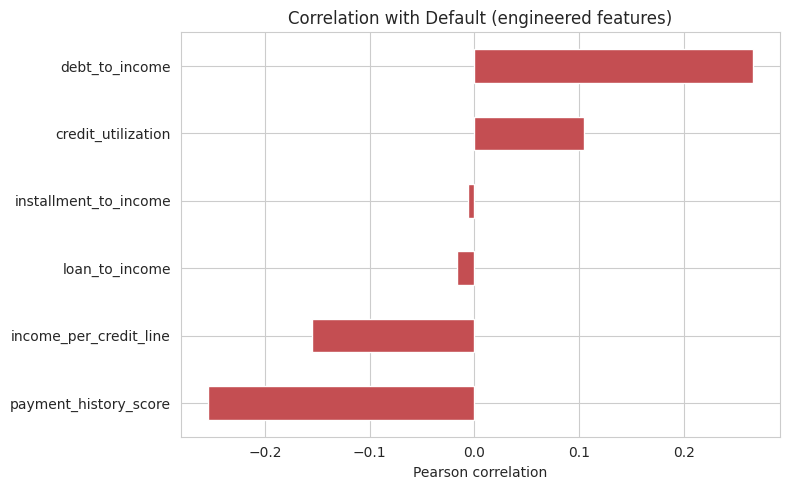

In [5]:
plt.figure(figsize=(8, 5))
corr = df_fe[engineered_cols + ["default"]].corr()["default"].drop("default").sort_values()
corr.plot(kind="barh", color="#C44E52")
plt.title("Correlation with Default (engineered features)")
plt.xlabel("Pearson correlation")
plt.tight_layout()
plt.show()

## 4. Train / Test Split & Scaling

In [6]:
feature_cols = [
    "age", "annual_income", "employment_years", "existing_loans", "total_debt",
    "credit_limit", "credit_card_balance", "missed_payments_24m",
    "loan_amount_requested", "loan_term_months", "num_credit_inquiries",
    "has_bankruptcy"
] + engineered_cols

X = df_fe[feature_cols]
y = df_fe["default"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=RANDOM_STATE, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Train: (3750, 18), Test: (1250, 18)


## 5. Model Training

Three classifiers, as specified in the brief:
- **Logistic Regression** — linear baseline, trained on scaled features
- **Decision Tree** — interpretable, non-linear, shallow depth to avoid overfitting
- **Random Forest** — ensemble of trees, usually the strongest of the three

In [7]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    "Decision Tree": DecisionTreeClassifier(max_depth=6, min_samples_leaf=20, random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(
        n_estimators=300, max_depth=8, min_samples_leaf=10, random_state=RANDOM_STATE
    ),
}

results = []
roc_data = {}
fitted_models = {}

for name, model in models.items():
    if name == "Logistic Regression":
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
        y_proba = model.predict_proba(X_test_scaled)[:, 1]
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        y_proba = model.predict_proba(X_test)[:, 1]

    fitted_models[name] = model

    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_proba)

    results.append({
        "Model": name, "Precision": precision, "Recall": recall,
        "F1-Score": f1, "ROC-AUC": roc_auc
    })

    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_data[name] = (fpr, tpr, roc_auc)

    print(f"\n--- {name} ---")
    print(classification_report(y_test, y_pred, target_names=["Good Credit", "Bad Credit"]))


--- Logistic Regression ---
              precision    recall  f1-score   support

 Good Credit       0.70      0.75      0.72       634
  Bad Credit       0.72      0.66      0.69       616

    accuracy                           0.71      1250
   macro avg       0.71      0.71      0.71      1250
weighted avg       0.71      0.71      0.71      1250


--- Decision Tree ---
              precision    recall  f1-score   support

 Good Credit       0.66      0.73      0.69       634
  Bad Credit       0.69      0.61      0.65       616

    accuracy                           0.67      1250
   macro avg       0.67      0.67      0.67      1250
weighted avg       0.67      0.67      0.67      1250


--- Random Forest ---
              precision    recall  f1-score   support

 Good Credit       0.70      0.70      0.70       634
  Bad Credit       0.69      0.70      0.69       616

    accuracy                           0.70      1250
   macro avg       0.70      0.70      0.70      1250

## 6. Model Comparison

In [8]:
results_df = pd.DataFrame(results).set_index("Model").round(4)
results_df

,Precision,Recall,F1-Score,ROC-AUC
Model,,,,
Logistic Regression,0.7221,0.6623,0.6909,0.7765
Decision Tree,0.6867,0.6120,0.6472,0.7115
Random Forest,0.6908,0.6964,0.6936,0.7630


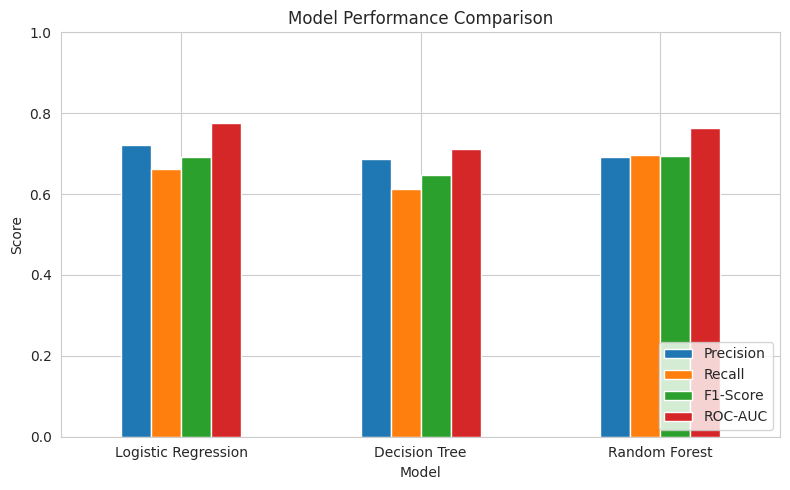

In [9]:
plt.figure(figsize=(8, 5))
results_df[["Precision", "Recall", "F1-Score", "ROC-AUC"]].plot(kind="bar", ax=plt.gca())
plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.ylim(0, 1)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

### ROC Curves

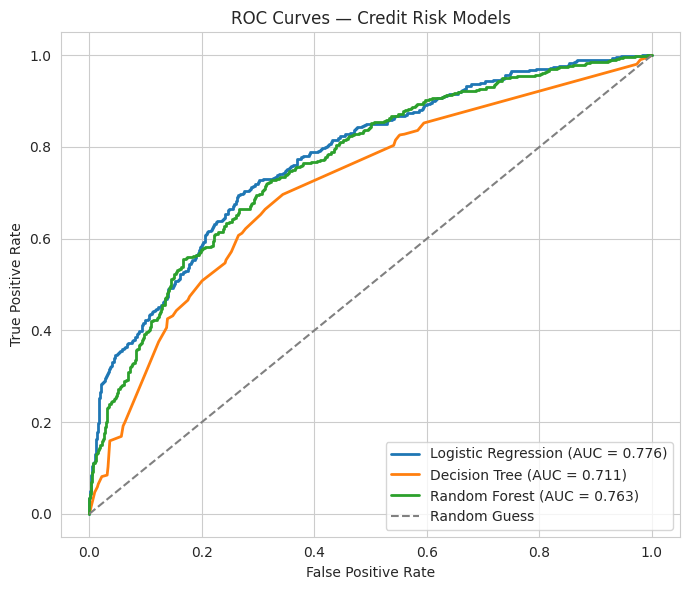

In [10]:
plt.figure(figsize=(7, 6))
for name, (fpr, tpr, auc) in roc_data.items():
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.3f})", linewidth=2)
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random Guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves — Credit Risk Models")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

### Confusion Matrices

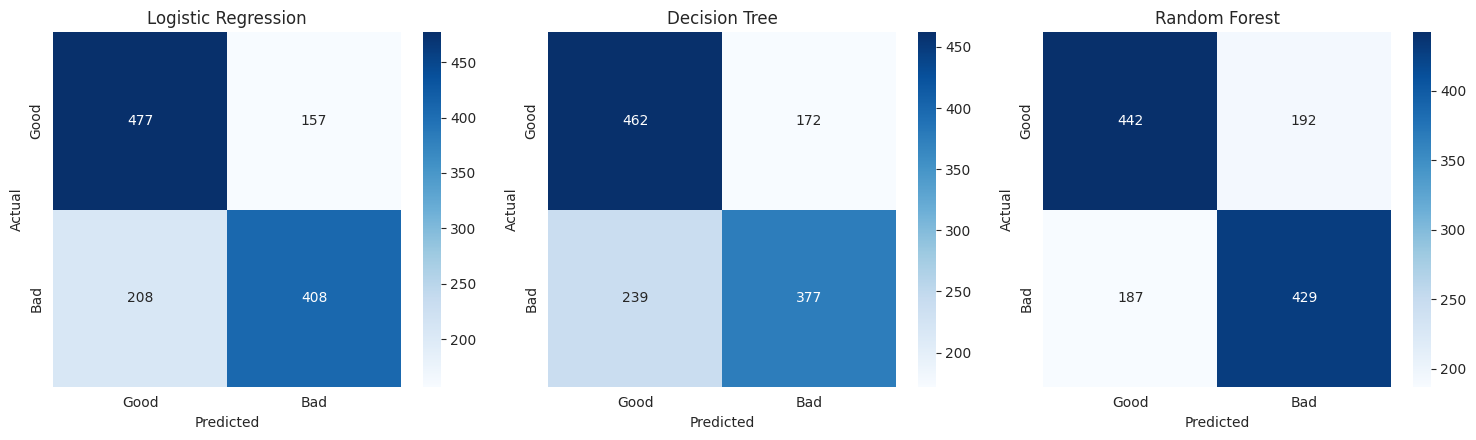

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, (name, model) in zip(axes, fitted_models.items()):
    X_eval = X_test_scaled if name == "Logistic Regression" else X_test
    y_pred = model.predict(X_eval)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["Good", "Bad"], yticklabels=["Good", "Bad"])
    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
plt.tight_layout()
plt.show()

## 7. Feature Importance (Random Forest)

Which features actually drive the model's predictions?

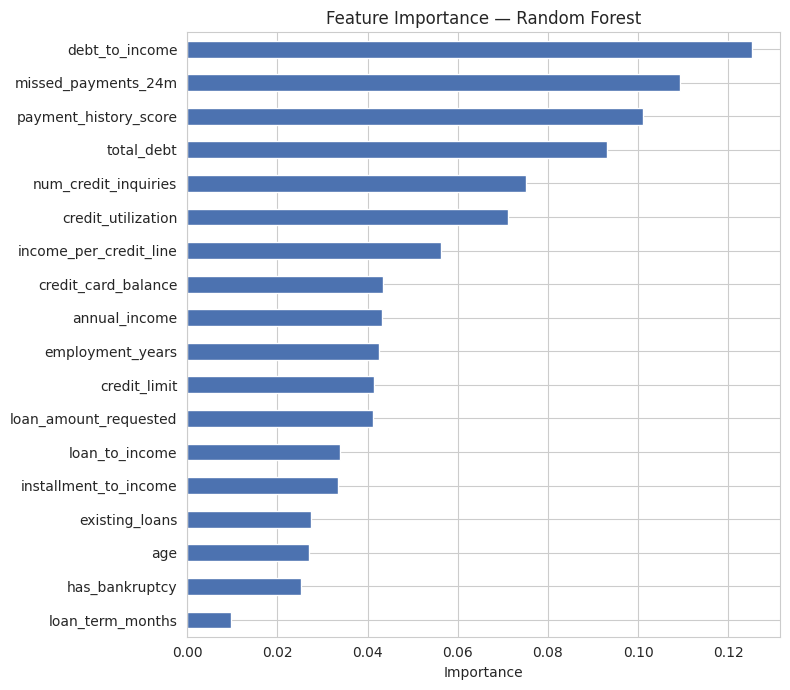

In [12]:
rf = fitted_models["Random Forest"]
importances = pd.Series(rf.feature_importances_, index=feature_cols).sort_values(ascending=True)

plt.figure(figsize=(8, 7))
importances.plot(kind="barh", color="#4C72B0")
plt.title("Feature Importance — Random Forest")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

## 8. Takeaways

- **Logistic Regression** performs best on ROC-AUC here because the synthetic labels were generated from a roughly linear/logistic risk function — a reminder that model choice should match the structure of your actual data, which you'd discover through EDA on real records.
- **Random Forest** gives the most balanced precision/recall and is usually the strongest performer on real-world, non-linear financial data.
- **Decision Tree** trades some accuracy for interpretability — useful when you need to explain individual rejection decisions (e.g. regulatory requirements like adverse action notices).
- Engineered ratios (`debt_to_income`, `credit_utilization`, `missed_payments_24m`) dominate feature importance, consistent with how real-world credit bureaus score risk.

### If you swap in real data
- Real default rates are typically far more imbalanced (5–15% bad vs ~50/50 here) — use class weighting, SMOTE, or threshold tuning, and don't rely on raw accuracy.
- Recall on "Bad Credit" usually matters more than overall accuracy — missing a defaulter is costlier than a false alarm.
- For regulatory environments, simpler models (Logistic Regression, shallow trees) are often preferred for explainability over Random Forest.